In [80]:
# Model Training Imports
from sklearn.model_selection import train_test_split
import torch

# Model Explainability Imports
from torch_geometric.nn import GCNConv
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

# visulisation Imports
import matplotlib.pyplot as plt

# Load Variables from Graph_PreProcessing File
import sys
from io import StringIO

# Suppress output from %run
old_stdout = sys.stdout
sys.stdout = StringIO()

%run "2__Graph_PreProcessing.ipynb"

sys.stdout = old_stdout

print("Data loaded successfully!")
print("y shape:", y.shape)


Data loaded successfully!
y shape: torch.Size([2835])


# Create Labeled Node List


If we train on ALL nodes:  


model will try learning from unlabeled nodes


which is impossible because : there is no correct answer

In [81]:
labeled_nodes = (y != -1).nonzero(as_tuple=True)[0]
print("Total Labeled Nodes :-" , len(labeled_nodes))
print(labeled_nodes[:10])


Total Labeled Nodes :- 178
tensor([ 14,  17,  22,  59,  66,  77,  78,  94, 117, 121])


# TRAIN/TEST SPLIT

In [82]:
train_nodes, test_nodes = train_test_split(
    labeled_nodes,
    test_size = 0.2,
    random_state = 42
)

print("Train Nodes :- ", len(train_nodes))
print("Test Nodes :- ", len(test_nodes))

Train Nodes :-  142
Test Nodes :-  36


# CREATE TRAIN/TEST MASKS
PyTorch Geometric uses masks to know which nodes belongs to test set & which for train set

In [83]:
# Empty mask for train & test dataset
train_mask = torch.zeros( num_nodes, dtype=torch.bool )
test_mask = torch.zeros( num_nodes, dtype=torch.bool )

In [84]:
# Set Train & Test Nodes
# Purpose
# Train Mask : Learn from these nodes
# Test Mask : Evalute on these nodes

train_mask[train_nodes] = True
test_mask[test_nodes] = True

# Varify
print(train_mask.sum())
print(test_mask.sum())

tensor(142)
tensor(36)


# CREATE NODE FEATURES
Each node gets a unique vector.


WHAT THIS CREATES
Something like : [1283, 9755]
| Rows    | Nodes                  |
| ------- | ---------------------- |
| Columns | node identity features |


In [85]:
x = torch.eye(num_nodes)
print(x.shape)

torch.Size([2835, 2835])


# CREATE PyTorch Geometric DATA OBJECT
This Object stores graph data inside it ,  specifically in Data() obj.

In [86]:
from torch_geometric.data import Data

data = Data(
    x = x, # Node Features
    edge_index = edge_index,
    edge_type = edge_type,
    y = y
)

data.train_mask = train_mask
data.test_mask = test_mask

print(data)

Data(x=[2835, 2835], edge_index=[2, 20338], y=[2835], edge_type=[20338], train_mask=[2835], test_mask=[2835])


# BUILD R-GCN MODEL
Create Neural Network

__init__() : Define Model Architecture.


Parameters Meaning
| Parameter         | Meaning                      |
| ----------------- | ---------------------------- |
| `num_nodes`       | feature size of nodes        |
| `hidden_channels` | hidden embedding size        |
| `num_classes`     | number of prediction classes |
| `num_relations`   | RDF relation types           |

In Our Project
| Variable          | Example Value |
| ----------------- | ------------- |
| `num_nodes`       | 2835          |
| `hidden_channels` | 16            |
| `num_classes`     | 5             |
| `num_relations`   | maybe 45      |

#### First RGCN Layer (conv1)

Purpose -- message passing (Each node update itself using Neighbour Information)


Input
2835-dimensional identity vector
Output
16-dimensional hidden embedding


#### Second RGCN Layer (conv2)

Purpose -- Creates output layer (5 Class Scores)


Input
16-dimensional hidden embedding
Output
5 class scores


Visual Flow
Layer 1:
2835 → 16

Layer 2:
16 → 5

In [87]:
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv

# Create a custom neural network model
class RGCN(torch.nn.Module): 

    def __init__(
            self,
            num_nodes,
            hidden_channels,
            num_classes,
            num_relations
    ):
        super().__init__()

        # learn graph embeddings
        self.conv1 = RGCNConv(
            num_nodes,
            hidden_channels,
            num_relations
        )

        # Predict node Classes
        self.conv2 = RGCNConv(
            hidden_channels,
            num_classes,
            num_relations
        )
    
    def forward( self, x, edge_index, edge_type ):
        x = self.conv1( x, edge_index, edge_type )
        x = F.relu(x)
        x = self.conv2( x, edge_index, edge_type )
        return x

# CREATE MODEL

In [88]:
num_relations = len(predicate_to_id)
num_classes = len(label_to_id)

model = RGCN(
            num_nodes = num_nodes,
            hidden_channels = 16,
            num_classes = num_classes,
            num_relations = num_relations
)

print(model)

RGCN(
  (conv1): RGCNConv(2835, 16, num_relations=24)
  (conv2): RGCNConv(16, 5, num_relations=24)
)


# Forward Passing

Purpose - graph learning + prediction


Inputs
| Input        | Meaning            |
| ------------ | ------------------ |
| `data.x`     | node features      |
| `edge_index` | graph connections  |
| `edge_type`  | RDF relation types |



R-GCN performs:

message passing, neighbor aggregation, relation-aware transformations, embedding learning


Output Explaination

| Dimension | Meaning      |
| --------- | ------------ |
| 2835      | nodes        |
| 5         | class scores |


In [89]:
out = model(
    data.x,
    data.edge_index,
    data.edge_type
)

print(out.shape)

torch.Size([2835, 5])


# LOSS FUNCTION & Optimizer
Loss function : Measures prediction error


Optimizer : Update model weights

Use Adam Optimizer

In [90]:
# Loss function
loss_function = torch.nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(), # Collect ALL Params. of R-GCN
    lr = 0.01 # Learning Rate
)

# TRAINING LOOP

Epoch - One complete learning Cycle
Training Iterations - 200


Why many Apochs ?
Intially weights are random, after many apochs weights gradually improve

Loss Measure : How wrong Predictions are...

BackPropogation : It computes gradients of the loss with respect to all model parameters.
Gradiants - how weights should move to reduce error


Suppose

loss = High

Backpropagation figures out:  which weights caused the mistake

And

How to Correct them

How to update weights

Formula : New weights = Old weights - Learning rate * Gradiant 

| Variable   | Value |
| ---------- | ----- |
| old weight | 0.8   |
| gradient   | 0.2   |
| lr         | 0.01  |

new weight = 0.798

TRAINING PIPELINE

1. Reset old gradients
        ↓
2. Make predictions
        ↓
3. Compute loss
        ↓
4. Compute gradients
        ↓
5. Update weights
        ↓
6. Repeat many times

In [91]:
for epoch in range(1, 201):

    # Step-1 : Model Train
    model.train()

    # Step-2 : clear old learning gradiants
    optimizer.zero_grad()

    # Step-3 : Forward Pass
    out = model(
        data.x,
        data.edge_index,
        data.edge_type
    )

    # Step-4 : Loss Calculation
    loss = loss_function(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    # Step-5 : BackwordPropogation
    loss.backward()

    # Update Weights
    optimizer.step()

    if epoch % 20 == 0:
        print(
            f"Epoch: {epoch}, Loss: {loss.item():.4f}"
        )

Epoch: 20, Loss: 0.1791
Epoch: 40, Loss: 0.0348
Epoch: 60, Loss: 0.0139
Epoch: 80, Loss: 0.0063
Epoch: 100, Loss: 0.0036
Epoch: 120, Loss: 0.0024
Epoch: 140, Loss: 0.0018
Epoch: 160, Loss: 0.0014
Epoch: 180, Loss: 0.0011
Epoch: 200, Loss: 0.0009


# Model Evaluation

WorkFlow :

Trained Model


Generate Predictions

Select Test Nodes

Compare with True Labels

Count Correct Predictions

Compute Accuracy

In [92]:
model.eval()

pred = out.argmax( dim = 1 )

correct = (
    pred[data.test_mask] == data.y[data.test_mask]
).sum()

accuracy = int(correct) / int(data.test_mask.sum())

print("Accuracy - ", accuracy)

Accuracy -  0.9444444444444444


# Explainability of the Model

In [93]:
# test_nodes represent Unseen Predictions
test_node = test_nodes[0]
print("Test Node : ", test_node)

Test Node :  tensor(258)


In [94]:
# CREATE SIMPLE GCN MODEL

class GCN(torch.nn.Module):

    def __init__(self, num_features, hidden_channels, num_classes):

        super().__init__()

        self.con1 = GCNConv(
            num_features,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            num_classes
        )
    
    def forward(self, x, edge_index):

        x = self.con1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# Create Model
gcn_model = GCN(
    num_features = data.x.shape[1],
    hidden_channels = 16,
    num_classes = num_classes
)

# Train GCN
# Forward Pass
out = gcn_model(
    data.x,
    data.edge_index
)

In [ ]:
# Explainer Code
explainer = Explainer(

    model = gcn_model,
    algorithm = GNNExplainer(
        epochs = 200
    ),
    explanation_type = "model",
    node_mask_type = "attributes",
    edge_mask_type = "object",
    model_config = dict(
        mode = "multiclass_classification",
        task_level = "node",
        return_type = "raw"
    )
)

# Generate Explaination
explaination_gnn = explainer(
    x = data.x,
    edge_index = data.edge_index,
    index = int(test_node)
)

Explanation(node_mask=[2835, 2835], edge_mask=[20338], prediction=[2835, 5], target=[2835], index=[1], x=[2835, 2835], edge_index=[2, 20338])
tensor([0., 0., 0.,  ..., 0., 0., 0.])


In [108]:
# Explore Explainations

print(explaination_gnn)
print(explaination_gnn.edge_mask.max())

Explanation(node_mask=[2835, 2835], edge_mask=[20338], prediction=[2835, 5], target=[2835], index=[1], x=[2835, 2835], edge_index=[2, 20338])
tensor(0.1130)


In [138]:
# Find out Top Edges
top_edges = explaination_gnn.edge_mask.topk(10)

# Extract indices from top_edges
important_edge_indices = top_edges.indices
print(important_edge_indices)

tensor([10858,   184, 10008, 18405,  6424, 16921,  6832, 17338,  4887, 16223])


Counter({'isAbout': 4, 'publication': 3, 'publishes': 2, 'author': 1})


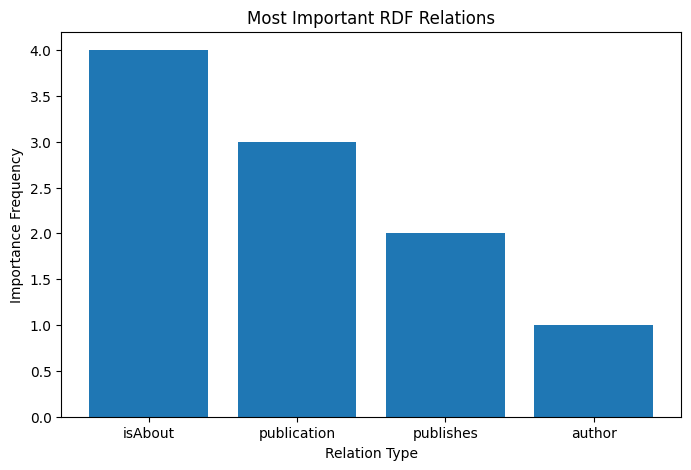

In [139]:
# Important Relation Frequency Plot

important_relations = []

for idx in important_edge_indices:

    idx = idx.item()
    rel_id = edge_type[idx].item()
    relation = id_to_relation[rel_id]
    clean_relation = relation.split("#")[-1]
    important_relations.append(clean_relation)

relation_counts = Counter(important_relations)
print(relation_counts)



# Visulisation (Bar Plot)
relations = list(relation_counts.keys())
counts = list(relation_counts.values())

plt.figure(figsize=(8,5))
plt.bar(relations, counts)
plt.xlabel("Relation Type")
plt.ylabel("Importance Frequency")
plt.title("Most Important RDF Relations")
plt.show()

In [122]:
subgraph = explaination_gnn.get_explanation_subgraph()

print(subgraph)

Explanation(node_mask=[112, 2835], edge_mask=[204], prediction=[112, 5], target=[112], index=[1], x=[112, 2835], edge_index=[2, 204])


Counter({'type': 6, 'isAbout': 4, 'publication': 4, 'isWorkedOnBy': 2, 'editor': 1, 'author': 1, 'publishes': 1, 'hasProject': 1})


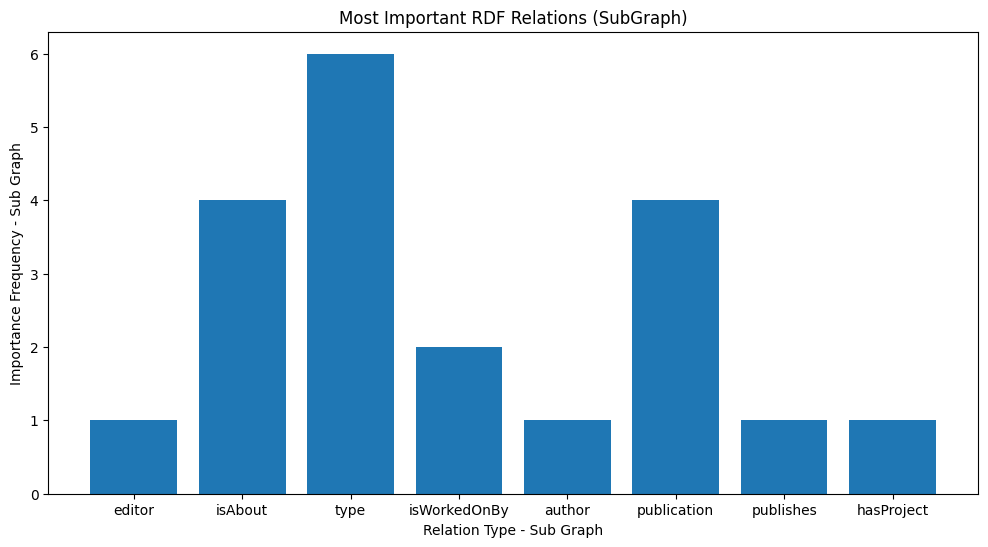

In [136]:
important_edge_indices = subgraph.edge_mask.topk(20).indices

# EXTRACT RELATION NAMES
important_relations = []

for idx in important_edge_indices:

    idx = idx.item()
    rel_id = edge_type[idx].item()
    relation = id_to_relation[rel_id]
    clean_relation = relation.split("#")[-1]
    important_relations.append(clean_relation)


relation_counts = Counter(important_relations)
print(relation_counts)

# Visulisation
relations = list(relation_counts.keys())
counts = list(relation_counts.values())

plt.figure(figsize=(12,6))
plt.bar(relations, counts)
plt.xlabel("Relation Type - Sub Graph")
plt.ylabel("Importance Frequency - Sub Graph")
plt.title("Most Important RDF Relations (SubGraph)")
plt.show()